<a href="https://colab.research.google.com/github/Ammar-creator-cmd/DataVisualization/blob/main/GenderPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [2]:
import pandas as pd
import re
import gdown
google_drive_link = "https://drive.google.com/file/d/1wfpbNWY4S39u5GuNxBr218N_gyXmCEUv/view?usp=drive_link"
file_id = re.search(r"/d/(\w+)/", google_drive_link).group(1)
# Define the output file name
output_file = 'genderprediction.csv'
# Download the file
gdown.download(f'https://drive.google.com/uc?id={file_id}', output_file, quiet=False)
# Load the dataset into a Pandas DataFrame
data = pd.read_csv(output_file)

Downloading...
From (original): https://drive.google.com/uc?id=1wfpbNWY4S39u5GuNxBr218N_gyXmCEUv
From (redirected): https://drive.google.com/uc?id=1wfpbNWY4S39u5GuNxBr218N_gyXmCEUv&confirm=t&uuid=f4d0ef0c-4dba-431e-acf5-002839fad872
To: /content/genderprediction.csv
100%|██████████| 200M/200M [00:03<00:00, 61.8MB/s]


In [3]:
data.head()

,age,ethnicity,gender,img_name,pixels
0,1,2,0,20161219203650636.jpg.chip.jpg,129 128 128 126 127 130 133 135 139 142 145 14...
1,1,2,0,20161219222752047.jpg.chip.jpg,164 74 111 168 169 171 175 182 184 188 193 199...
2,1,2,0,20161219222832191.jpg.chip.jpg,67 70 71 70 69 67 70 79 90 103 116 132 145 155...
3,1,2,0,20161220144911423.jpg.chip.jpg,193 197 198 200 199 200 202 203 204 205 208 21...
4,1,2,0,20161220144914327.jpg.chip.jpg,202 205 209 210 209 209 210 211 212 214 218 21...


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23705 entries, 0 to 23704
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        23705 non-null  int64 
 1   ethnicity  23705 non-null  int64 
 2   gender     23705 non-null  int64 
 3   img_name   23705 non-null  object
 4   pixels     23705 non-null  object
dtypes: int64(3), object(2)
memory usage: 926.1+ KB


In [5]:
data["gender"].value_counts()

,count
gender,
0,12391
1,11314


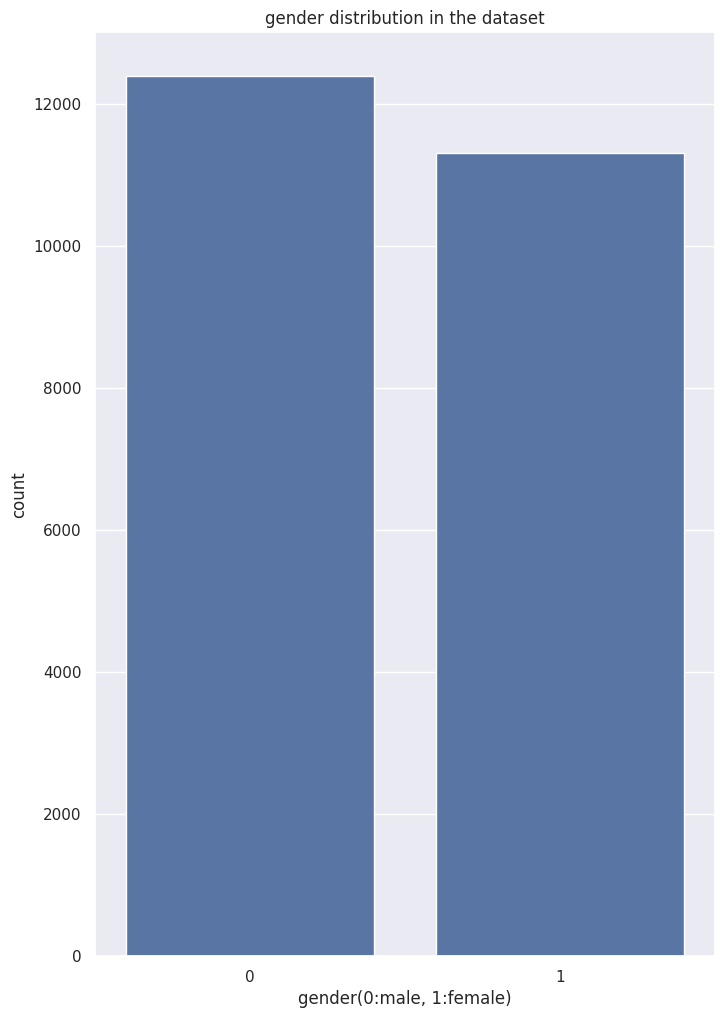

In [6]:
plt.figure(figsize = (8, 12))
sns.countplot(data = data, x = "gender")
plt.xlabel("gender(0:male, 1:female)")
plt.ylabel("count")
plt.title("gender distribution in the dataset")
plt.show()

In [7]:
import numpy as np
# Map the 'pixels' column by splitting the space-separated string, converting to float32, and reshaping into 48x48 arrays
data['pixels'] = data['pixels'].map(lambda x: np.array(x.split(' '), dtype=np.float32).reshape(48, 48))


### feature and target

In [8]:
#extract pixel data from the dataframe and convert it to a numpy array
images = np.array(data["pixels"].to_list())

#extract the "gender" column values as labels
labels = data["gender"].values

### data transformation

# Reshape the array to have a 4D shape (number of samples, width, height, number of channels)
# In this case, the images are grayscale, so the number of channels is 1

In [9]:
images_reshaped = images.reshape(images.shape[0], 48, 48, 1)

### data normalization

# Check if the maximum pixel value in the images array is greater than 1

In [10]:
if np.max(images_reshaped)>1:
  #Normalize the pixel values by dividing by 255
  images_reshaped = images_reshaped / 255

###Data Splitting

In [11]:
from sklearn.model_selection import train_test_split

#split the data into training and testing sets
train_images, test_images, train_labels, test_labels = train_test_split(images_reshaped, labels, test_size = 0.2, random_state = 42)

In [12]:
#further split and testing set into testing and validation sets
test_images, val_images, test_labels, val_labels = train_test_split(test_images, test_labels, test_size = 0.5, random_state = 42)

In [13]:
#print the sizes of the resulting sets
print(f"Training set size : {train_images.shape[0]} samples")
print(f"Validation set size : {val_images.shape[0]} samples")
print(f"Testing set size : {test_images.shape[0]} samples")

Training set size : 18964 samples
Validation set size : 2371 samples
Testing set size : 2370 samples


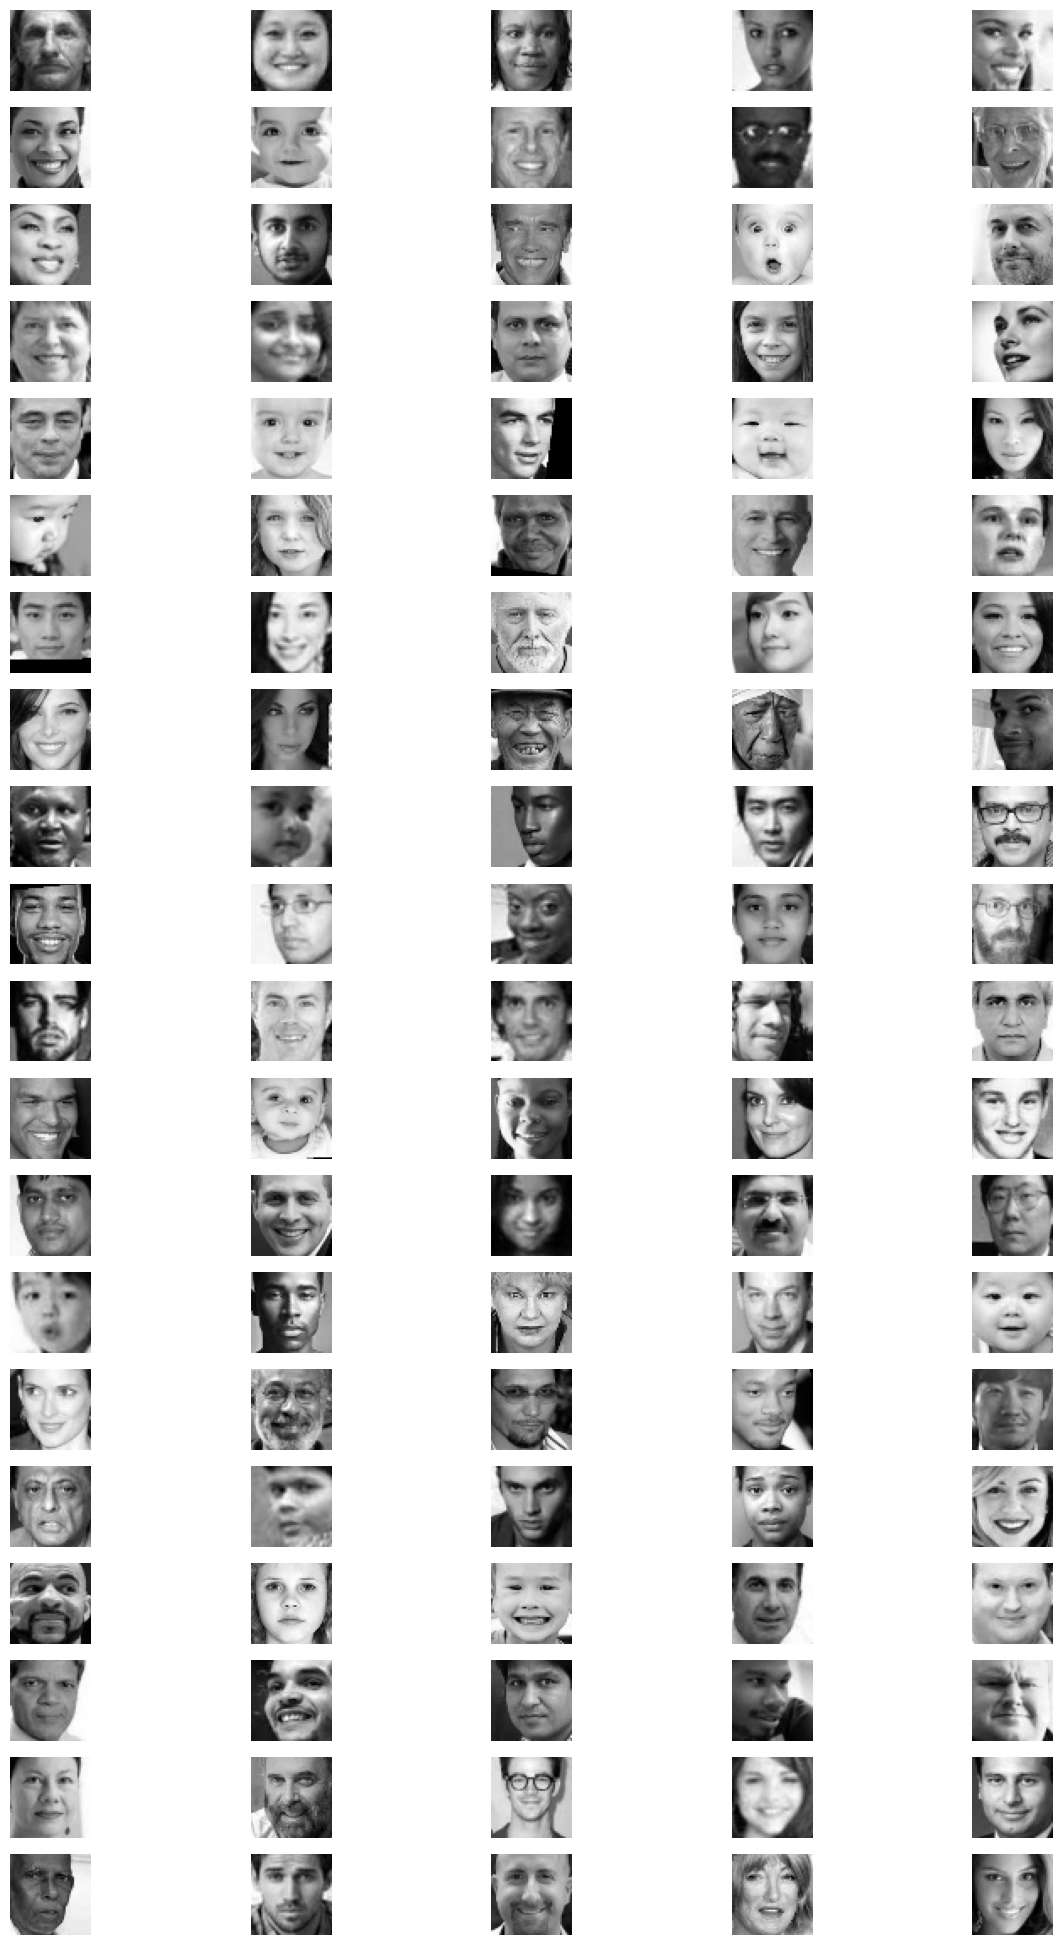

In [14]:
#plot 100 random grayscale images
fig, axes = plt.subplots(20, 5, figsize = (15, 25))

for row in range(20):
  for col in range(5):
    random_face = np.random.choice(len(data))
    image = data["pixels"][random_face]

    axes[row, col].imshow(image, cmap = "gray")
    axes[row, col].axis("off")

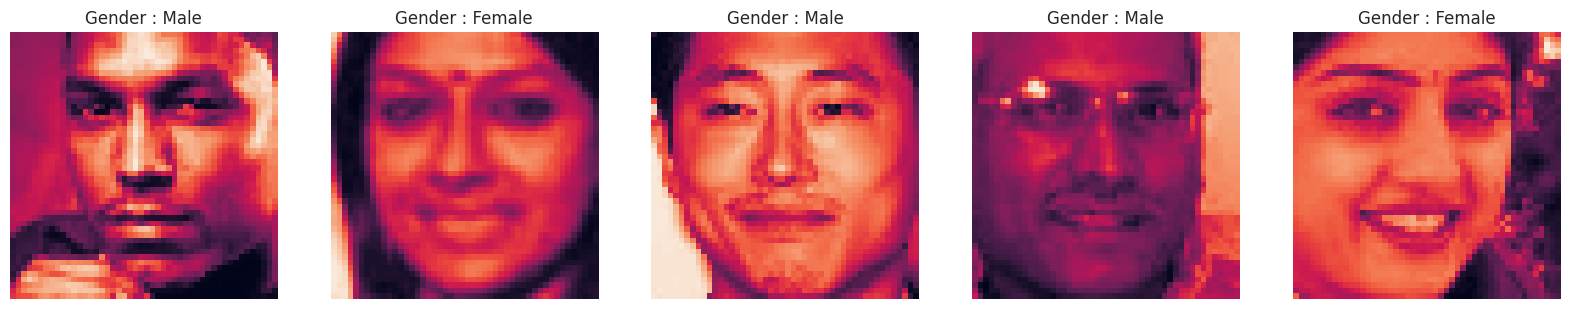

In [15]:
#plot some pics
fig, axes = plt.subplots(1, 5, figsize = (20, 10))

#randomly select and display 5 faces with their gender labels
for i in range(5):
  random_face = np.random.choice(len(data))

  gender = data["gender"][random_face]

  axes[i].set_title("Gender : {}".format("Female" if gender else "Male"))
  axes[i].imshow(data["pixels"][random_face])
  axes[i].axis("off")

### define variables

In [24]:
input_shape = train_images.shape[1:] # define the input shape for the neural netwrok (shape of each image).
n_epochs = 1 # define the num. of training epochs,
batch_size = 64 #set the batch size for training

### model architecture

In [17]:
#import necessary libraries
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from keras.layers import Flatten, Dense, Dropout

In [19]:
#create a sequential model
model = Sequential()

#add a 2d convultional layer with 64 filters and 3x3 kernel, specifyinh the input shape ReLU activation
model.add(Conv2D(64, kernel_size = (3, 3), input_shape = input_shape, activation = "relu"))

#add 2d max-pooling layer with 2x2 pool size
model.add(MaxPooling2D(pool_size = (2, 2)))

# Add BatchNormalization layer to normalize layer inputs
model.add(BatchNormalization())
# Add another convolutional layer with 128 filters and ReLU activation
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
# Add a max-pooling layer, a dropout layer (regularization), and another BatchNormalization layer
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))
model.add(BatchNormalization())
# Add two more convolutional layers with 256 filters each, ReLU activation, and a combination of max-pooling, dropout, and BatchNormalization
model.add(Conv2D(256, kernel_size=(3, 3), activation='relu'))
model.add(Conv2D(256, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.5))
model.add(BatchNormalization())
# Flatten the output from convolutional layers
model.add(Flatten())
# Add two dense (fully connected) layers with ReLU activation, one with dropout for regularization
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.4))
# Create the output layer for binary classification using a sigmoid activation
model.add(Dense(1, activation='sigmoid'))
# Compile the model with the Adam optimizer, binary cross-entropy loss, and accuracy metric
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# Print a summary of the model architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 46, 46, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 23, 23, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,109,121 (4.23 MB)

 Trainable params: 1,108,225 (4.23 MB)

 Non-trainable params: 896 (3.50 KB)

**Arsitektur ini adalah CNN yang cukup dalam (deep CNN) dengan kombinasi:**

Conv2D + Pooling → ekstraksi fitur visual.

BatchNormalization → stabilisasi distribusi input.

Dropout → regularisasi untuk mencegah overfitting.

Dense + Sigmoid → klasifikasi akhir ke dua kelas.

### Early Stopping Mechanism

In [22]:
#import necessary callbacks from Keras
from keras.callbacks import EarlyStopping,  ReduceLROnPlateau

#define a list of callbacks
callbacks = [EarlyStopping(patience = 4, monitor = "val_accuracy", mode = "max"), #EarlyStopping to prevent overfitting
             ReduceLROnPlateau(patience = 2, verbose = 1) #reduce learning rate on plateau
             ]

In [25]:
#fit the model to the training data
history = model.fit(train_images, train_labels, #training data and labels
                    epochs = n_epochs, #number of training epochs
                    batch_size = batch_size, #batch size for training
                    validation_data = (val_images, val_labels)) #validation for data and labels

297/297 ━━━━━━━━━━━━━━━━━━━━ 391s 1s/step - accuracy: 0.8433 - loss: 0.3518 - val_accuracy: 0.8596 - val_loss: 0.3246


In [29]:
#evaluate the model on testing data
test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose = 0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%") # .2f means 2 decimals

Test Accuracy: 86.16%


75/75 ━━━━━━━━━━━━━━━━━━━━ 15s 200ms/step


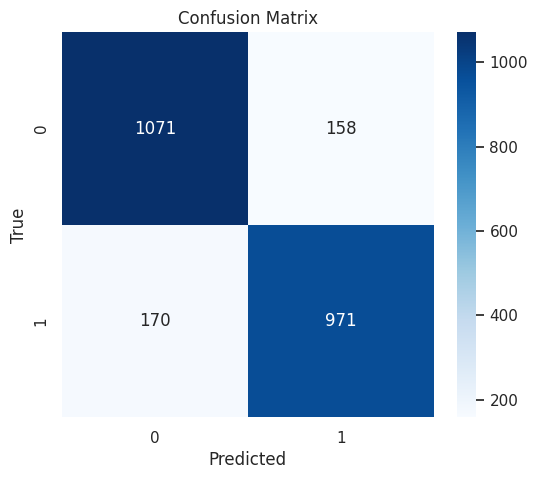

In [31]:
#import necessary libraries
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#generate predictions from the model
predictions = model.predict(test_images).flatten()
label_true = test_labels

#convert predicted probabilites to binary predictions (True/False)
label_pred = np.round(predictions)
#create a confusion matrix to visualize model performance
cm = confusion_matrix(label_true, label_pred)

#setup the figure for visualuzation
plt.figure(figsize = (6, 5))

# Create a heatmap of the confusion matrix with annotations
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
# Label the axes and set the title
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
# Show the visualization
plt.show()